# Train DQN

DQN learns a discrete action-value function from replayed transitions while a target network stabilizes its bootstrap targets. This example enables the Double DQN target:

$$y_t = r_{t+1} + \gamma(1-d_t) Q_{\theta^-}\!\left(s_{t+1}, \arg\max_{a'} Q_\theta(s_{t+1}, a')\right),$$

where $r_{t+1}$ is the reward, $\gamma$ the discount factor, $d_t$ the terminal indicator, $Q_\theta$ the online network, and $Q_{\theta^-}$ the target network. Set `double_dqn=False` for the original DQN target. This notebook trains on `CartPole-v1`, which has vector observations and two discrete actions, using epsilon-greedy exploration before plotting and evaluating the learned policy.

In [1]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

from aprenderl import DQN, DQNConfig
from aprenderl.utils import evaluate_policy

ENV_ID = "CartPole-v1"

In [2]:
env = gym.make(ENV_ID)
config = DQNConfig(
    double_dqn=True,
    buffer_size=8_000,
    learning_starts=500,
    target_update_interval=250,
    exploration_steps=2_000,
    seed=7,
)

agent = DQN(env, config=config, device="cpu")
agent.learn(total_timesteps=10_000)
env.close()

DQN:   0%|          | 0/10000 [00:00<?, ?step/s]

/home/pablo/workspace/AprendeRL/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:484: UserWarning: Found GPU0 NVIDIA GeForce GTX 960M which is of compute capability (CC) 5.0.
The following list shows the CCs this version of PyTorch was built for and the hardware CCs it supports:
- 7.5 which supports hardware CC >=7.5,<8.0
- 8.0 which supports hardware CC >=8.0,<9.0 except {8.7}
- 8.6 which supports hardware CC >=8.6,<9.0 except {8.7}
- 9.0 which supports hardware CC >=9.0,<10.0
- 10.0 which supports hardware CC >=10.0,<11.0 except {10.1}
- 12.0 which supports hardware CC >=12.0,<13.0
Your installed torch==2.14.0+cu130 does not include kernels for this GPU. Reinstall the same version against a CUDA build that does, e.g.:
  For CUDA 12.6 use pip install torch==2.14.0 --index-url https://download.pytorch.org/whl/cu126
  _warn_unsupported_code(d, device_cc, code_ccs)
/home/pablo/workspace/AprendeRL/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:602: UserWarning: 
NVIDIA

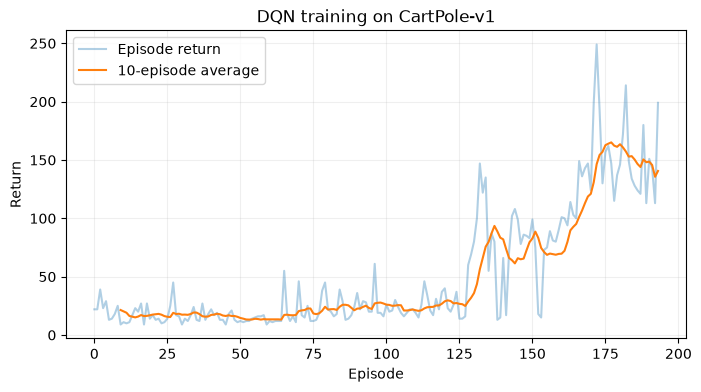

In [3]:
returns = np.asarray(agent.episode_returns)
window = min(10, len(returns))
moving_average = np.convolve(returns, np.ones(window) / window, mode="valid")

plt.figure(figsize=(8, 4))
plt.plot(returns, alpha=0.35, label="Episode return")
plt.plot(
    np.arange(window - 1, len(returns)),
    moving_average,
    label=f"{window}-episode average",
)
plt.xlabel("Episode")
plt.ylabel("Return")
plt.title(f"DQN training on {ENV_ID}")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## Watch the trained policy

This opens a window and runs 5 episodes using deterministic actions.

In [4]:
evaluation_env = gym.make(ENV_ID, render_mode="human")
try:
    result = evaluate_policy(
        agent, evaluation_env, episodes=5, deterministic=True, seed=1_000
    )
finally:
    evaluation_env.close()

print("Episode returns:", result.returns)
print(f"Mean return: {result.mean_return:.1f} +/- {result.return_std:.1f}")

Episode returns: (145.0, 164.0, 137.0, 218.0, 133.0)
Mean return: 159.4 +/- 31.2
